# Info + Bayesian board — Filimonov

**Audience:** research → desk (monitor / exec throttle / MM pull — **not α**).  
**Panel:** ETH+BTC · HL+Deribit+Kraken · days 2026-09-25/26/27/30 · n_native_complete=16.  
**Artifacts:** `out/feature_stats/` · `out/bayes/` · wire-as [`APPLICATIONS.md`](../APPLICATIONS.md).  
**Honesty:** 0 Promote. Bayesian posteriors are **decision quantities**, not greenlit edges.


## What information do these events carry?

| Event | Information hypothesis | Empiric (this dig) | Desk read |
|-------|------------------------|--------------------|-----------|
| Quote storm | Toxicity / adverse selection vs placebo | AS Δ≈+0.52bps but n=2 storm-days; P(AS\|storm) CrI covers 0.5 | Monitor / soft throttle only |
| Book fade | Temporary liquidity pull → spread widen; temp vs perm impact | IRF peak **−0.11bps** (unstable vs prior +0.28); P(fade)≈0.011 CrI tight; P(widen\|fade)≈0.60 wide CrI | MM pull sketch, not Promote |
| Ignition | Distinct cause sequence vs Nanex/V; forward markout | Markout +1.6bps CI[0.97,2.14] BH-reject but sparse; unique_mass still Hold | Escalate-vs-crash label only |
| Clock | Algo-hunter excess vs funding windows | Prior expand ratio≈0.57 | Monitor, no auto-trade |
| OFI/VPIN join | Regime context around storms | Prior expand OFI–ret≈0.42; VPIN≈0.58 | Same-panel tile, not α |
| Xvenue fade IS | Info share home↔far | Sparse Hasbrouck IS | Research-only |


In [1]:
from pathlib import Path
import json
from IPython.display import Image, display, Markdown

BOOK = Path('..').resolve()
fs = json.loads((BOOK / 'out/feature_stats/feature_stats.json').read_text())
by = json.loads((BOOK / 'out/bayes/bayes_layer.json').read_text())
print('feature_stats figs:', len(fs.get('fig_paths', [])))
print('bayes figs:', len(by.get('fig_paths', [])))
print('n_native', by.get('n_native_complete'))


feature_stats figs: 8
bayes figs: 7
n_native 16


## Bayesian decision quantities


In [2]:
rows = [
    ('P(fade)', by['fade_posterior']),
    ('λ storms/h HL', by['storm_rate_posterior']),
    ('λ ign / day-venue', by['ignition_rate_posterior']),
    ('P(AS|storm)', by['adverse_given_storm']),
    ('P(widen|fade)', by['widen_given_fade']),
]
for name, p in rows:
    print(f"{name:20s} mean={p['mean']:.4g}  CrI95={p['cri95']}")
print('\nPrior note:', by.get('prior_note', '')[:200], '...')


P(fade)              mean=0.0114  CrI95=[0.010763347564529603, 0.012045387396346528]
λ storms/h HL        mean=0.4091  CrI95=[0.3157684367607861, 0.514429357322877]
λ ign / day-venue    mean=6.412  CrI95=[5.264725996804694, 7.670159428841108]
P(AS|storm)          mean=0.4314  CrI95=[0.29990722092754357, 0.5679395649344342]
P(widen|fade)        mean=0.6  CrI95=[0.19412044968324338, 0.932414013511457]

Prior note: Default priors: Beta(1,1) / Gamma(1,1). Sensitivity includes Jeffreys and skeptical Beta(1,19)/Beta(1,99). Hierarchical uses moment-matched EB hyperparams blended 50/50 with weak prior. Laplace logist ...


### `out/bayes/figs/fig_posterior_fade.png`

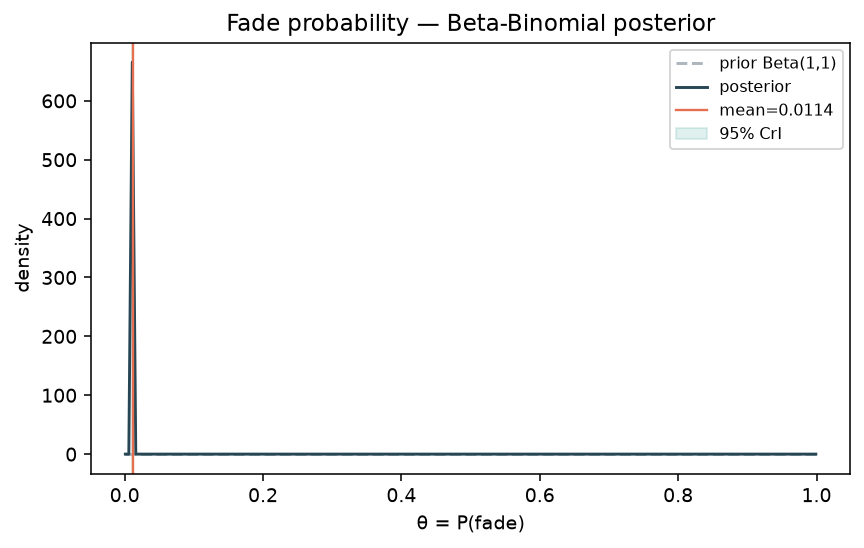

### `out/bayes/figs/fig_posterior_storm_rate.png`

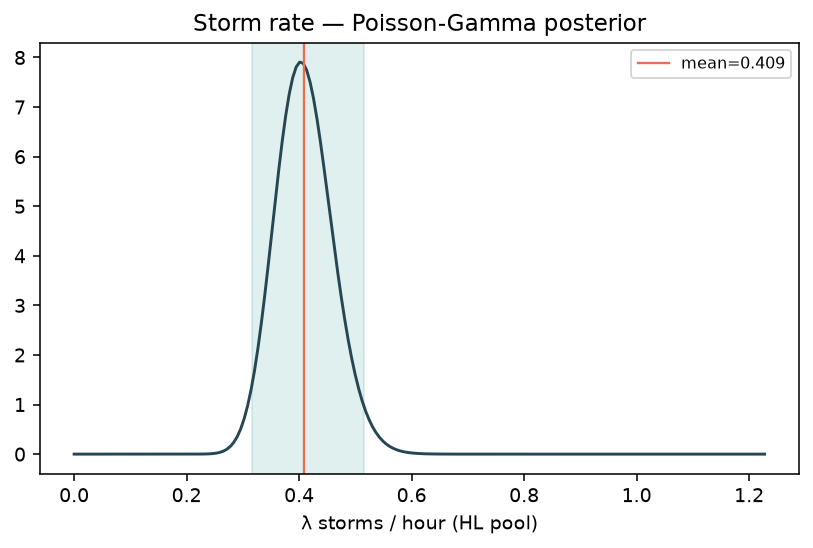

### `out/bayes/figs/fig_forest_prob.png`

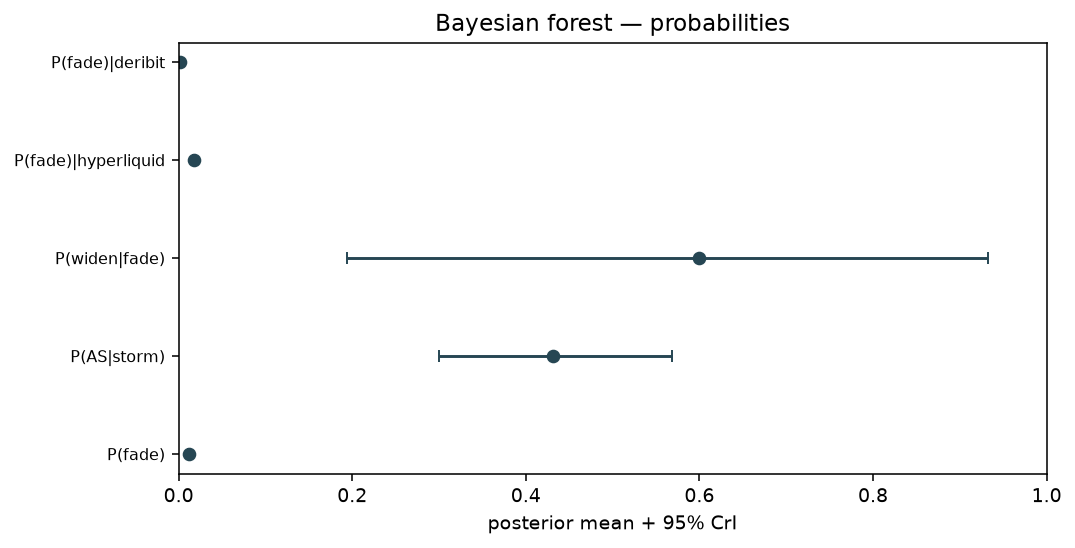

### `out/bayes/figs/fig_forest_rates.png`

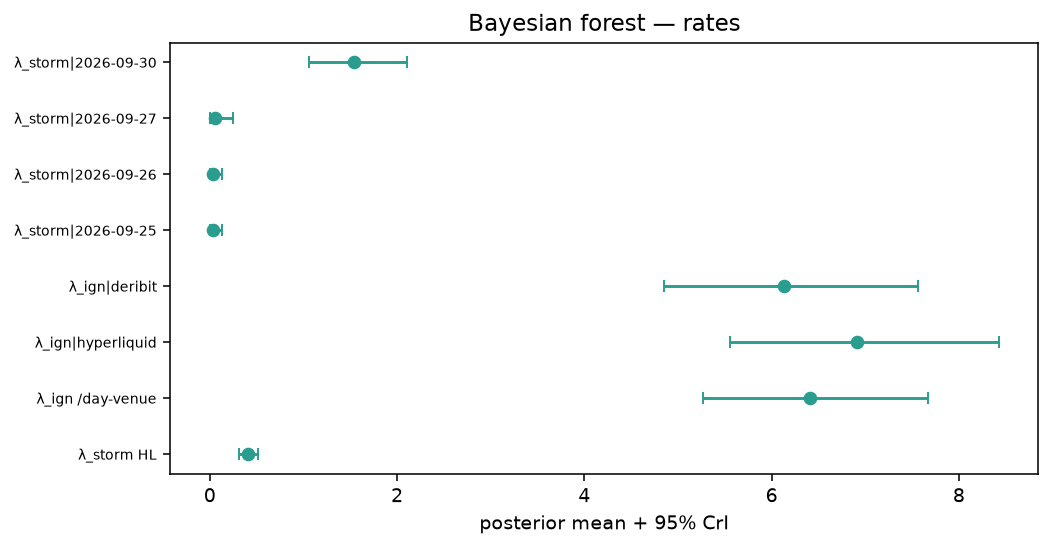

### `out/bayes/figs/fig_prior_sensitivity_fade.png`

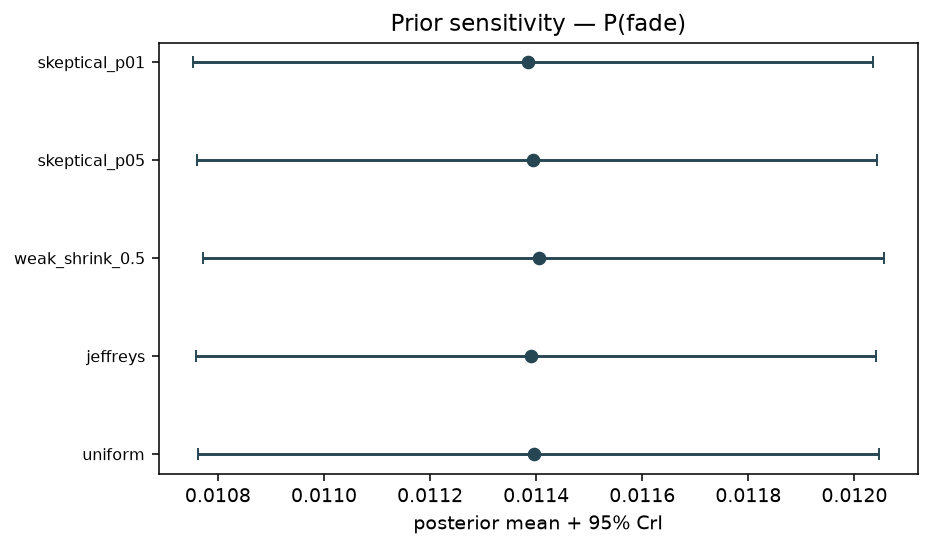

### `out/bayes/figs/fig_ppc_fade.png`

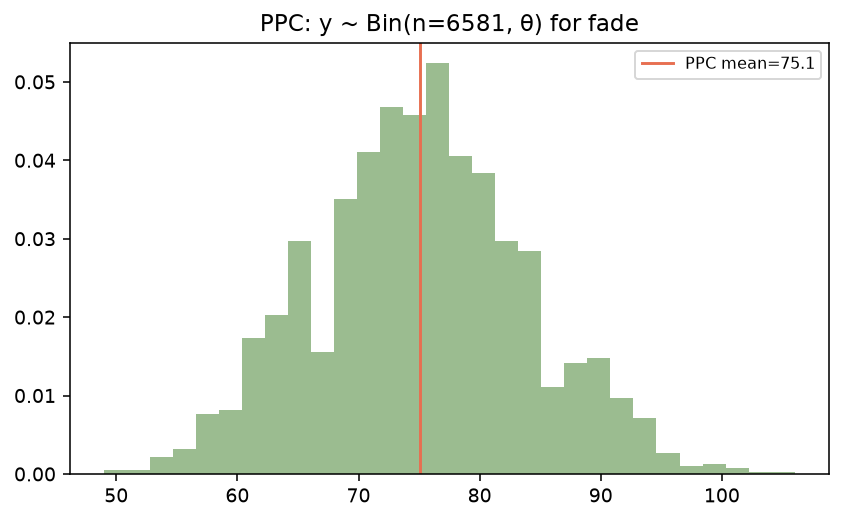

### `out/bayes/figs/fig_logit_adverse.png`

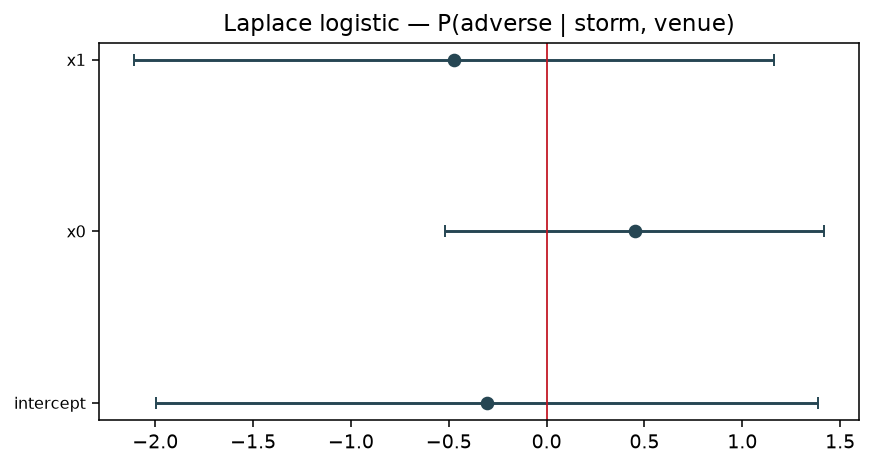

In [3]:
for rel in by.get('fig_paths', []):
    p = BOOK / rel
    display(Markdown(f'### `{rel}`'))
    if p.is_file():
        display(Image(filename=str(p)))


## Predictive / research usefulness (frequentist hygiene)


In [4]:
eps = fs['analysis']['predictive']['endpoints']
for e in eps:
    print(e['id'])
    print(' ', e['why'])
    print('  early/late stable:', e['sign_stable'], '| BH reject:', e['reject_bh'])


info.storm_adverse_selection
  point=0.5231 CI95=[0.4794,0.5668] BH_reject=True sign_stable=False n_days=2
  early/late stable: False | BH reject: True
info.fade_spread_widen_irf
  point=-0.1061 CI95=[-0.1871,-0.025] BH_reject=False sign_stable=False n_days=2
  early/late stable: False | BH reject: False
info.fade_markout_1s
  point=15.55 CI95=[0.2056,45.75] BH_reject=False sign_stable=True n_days=14
  early/late stable: True | BH reject: False
info.storm_markout_1s
  point=0.6282 CI95=[0.5926,0.6464] BH_reject=True sign_stable=False n_days=3
  early/late stable: False | BH reject: True
info.ignition_markout_1s
  point=1.597 CI95=[0.9712,2.142] BH_reject=True sign_stable=True n_days=6
  early/late stable: True | BH reject: True
info.fade_temp_vs_perm_impact
  point=481.7 CI95=[0.9453,1442] BH_reject=False sign_stable=True n_days=14
  early/late stable: True | BH reject: False


### `out/feature_stats/figs/fig_univariate_means.png`

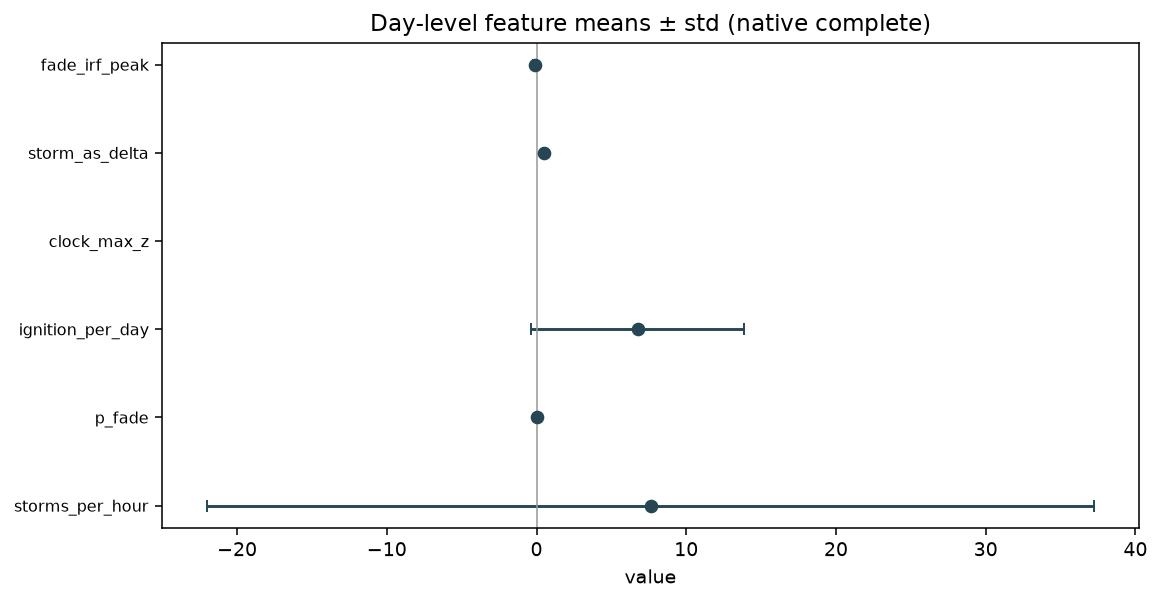

### `out/feature_stats/figs/fig_intensity_moments.png`

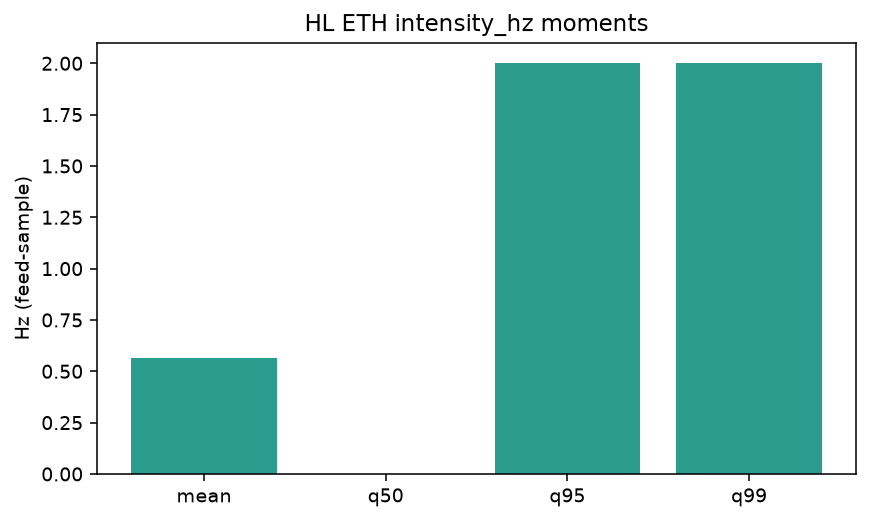

### `out/feature_stats/figs/fig_tod_storms.png`

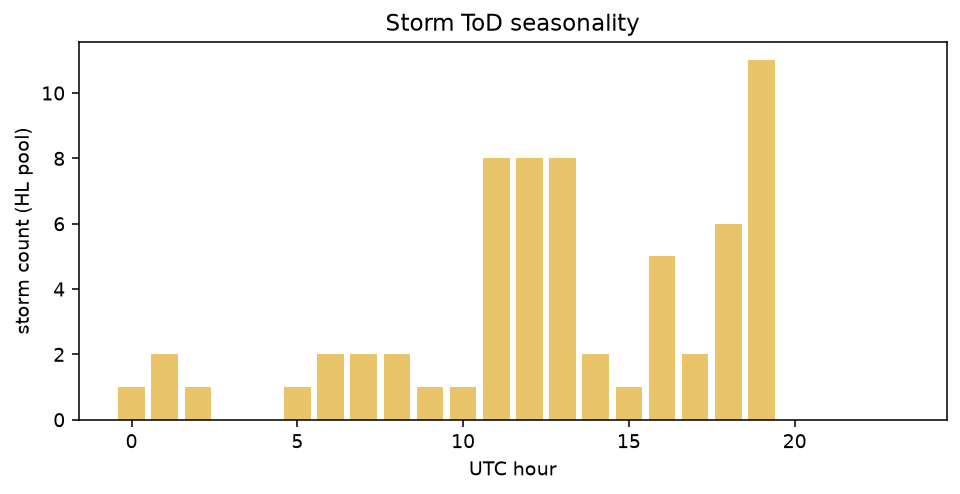

### `out/feature_stats/figs/fig_corr_spearman.png`

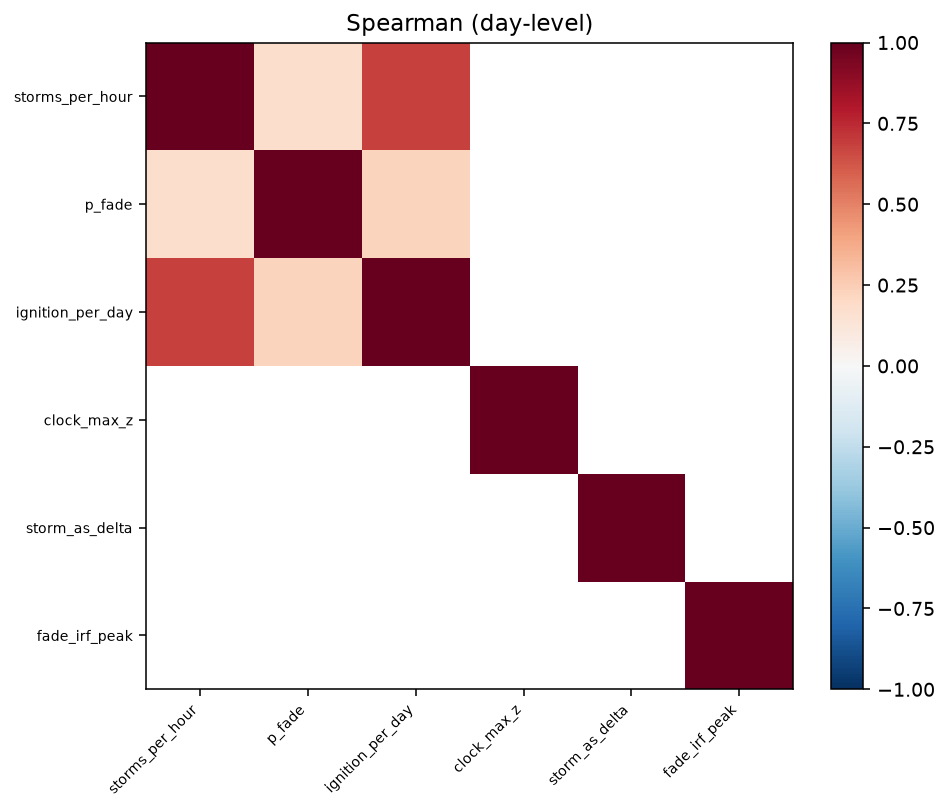

### `out/feature_stats/figs/fig_lead_lag_xcorr.png`

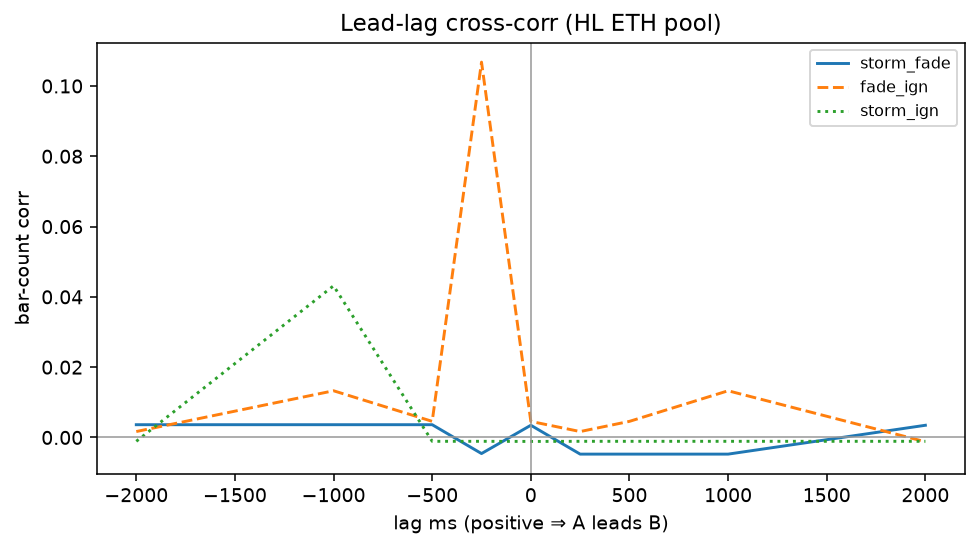

### `out/feature_stats/figs/fig_predictive_forest.png`

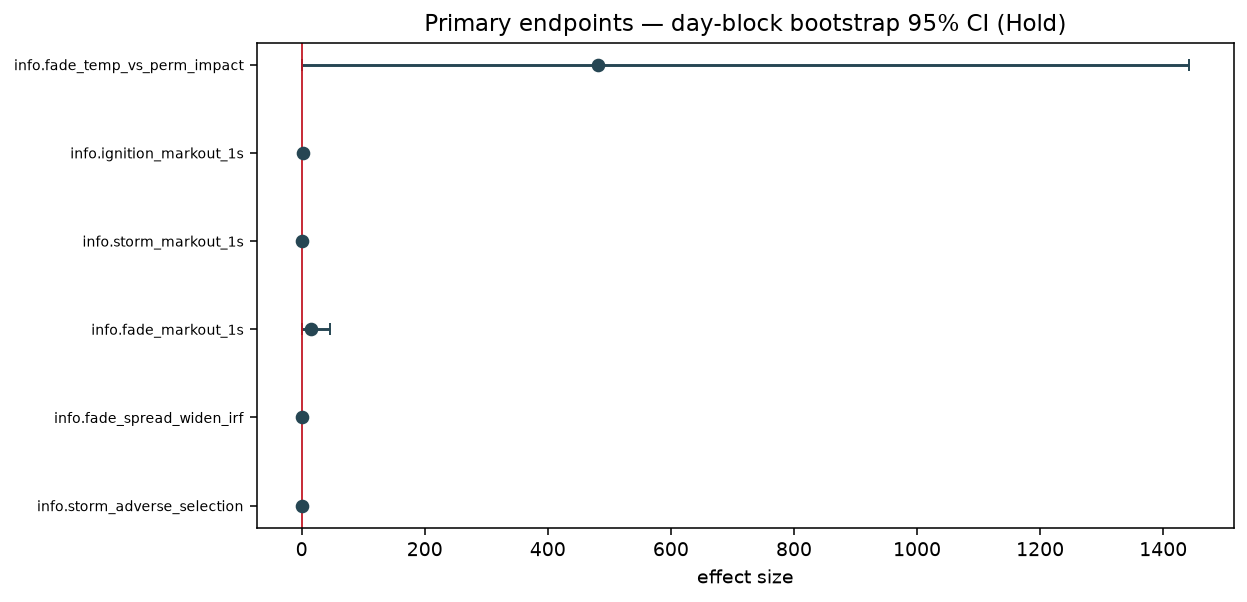

### `out/feature_stats/figs/fig_markout_horizons.png`

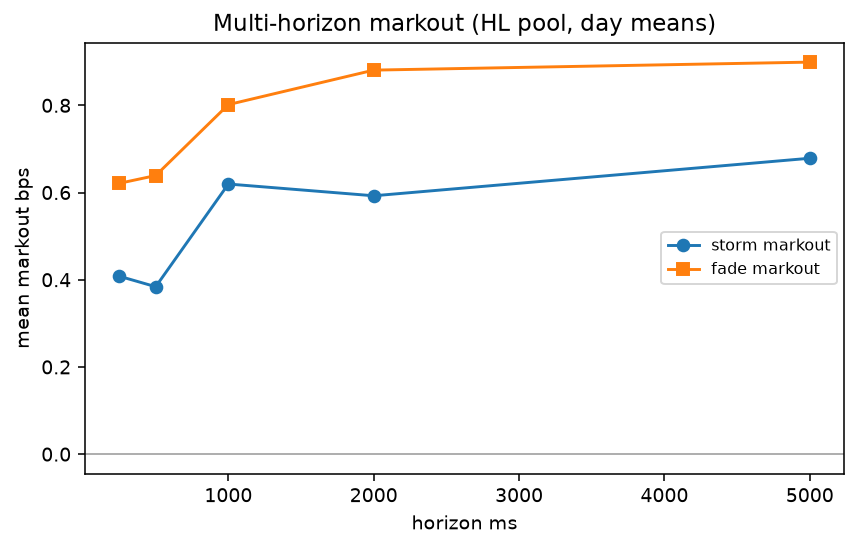

### `out/feature_stats/figs/fig_completeness.png`

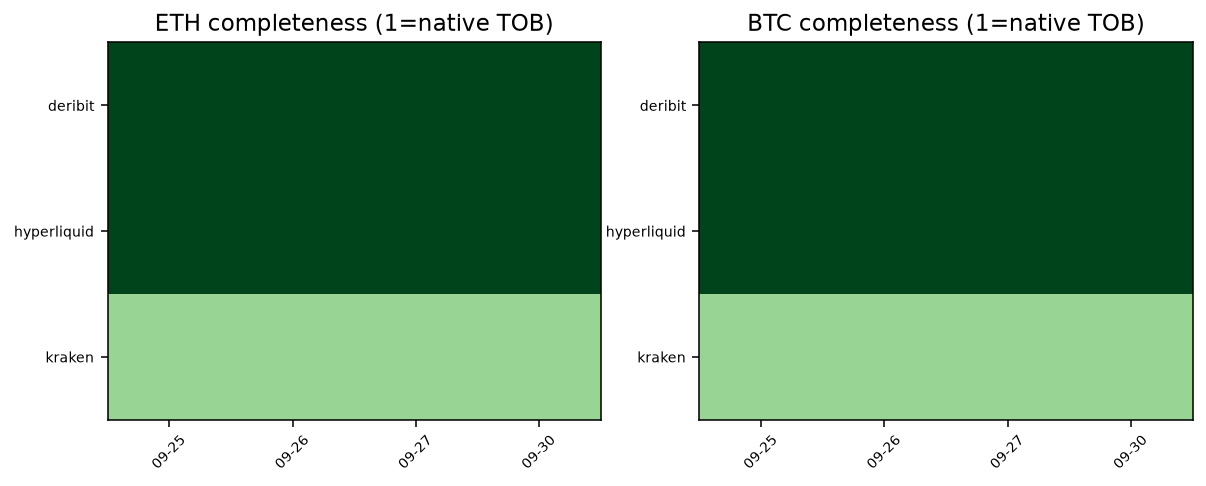

In [5]:
for rel in fs.get('fig_paths', []):
    p = BOOK / rel
    display(Markdown(f'### `{rel}`'))
    if p.is_file():
        display(Image(filename=str(p)))


## Candidate decisions (new Bayesian / info objects)

All **Hold**. Promote gates: ≥10 complete UTC days, BH + sign-stable, CrI clear of null, non-vacuous storm mass, overlap gates vs crash/lob.


In [6]:
cands = by.get('candidates', []) + [c for c in fs.get('candidates', []) if c['id'] not in {x['id'] for x in by.get('candidates', [])}]
for c in cands:
    print(f"{c['decision']:6s} {c['id']}")
    print('      ', c.get('why', '')[:120])


Hold   info.bayes_fade_p_posterior
       P(fade) posterior mean=0.0114 CrI95=[0.010763347564529603, 0.012045387396346528] n=105302
Hold   info.bayes_storm_rate_venue
       HL storms/h posterior mean=0.4091 CrI95=[0.3157684367607861, 0.514429357322877]
Hold   info.bayes_ignition_rate_venue
       ignition/day-venue mean=6.412 CrI95=[5.264725996804694, 7.670159428841108]
Hold   info.bayes_adverse_given_storm
       P(adverse|storm) mean=0.4314 CrI95=[0.29990722092754357, 0.5679395649344342] logit_storm_coef=0.44986977103772785
Hold   info.bayes_widen_given_fade
       P(widen|fade) mean=0.6 CrI95=[0.19412044968324338, 0.932414013511457]
Hold   info.fade_temp_vs_perm_impact
       multi-horizon markout temp/perm share from feature_stats companion
Hold   info.storm_adverse_selection
       point=0.5231 CI95=[0.4794,0.5668] BH_reject=True sign_stable=False n_days=2
Hold   info.fade_spread_widen_irf
       point=-0.1061 CI95=[-0.1871,-0.025] BH_reject=False sign_stable=False n_days=2
Hold 

## Research → desk map (summary)

See full table in [`APPLICATIONS.md`](../APPLICATIONS.md) § Research→desk map.

- **Storm λ posterior** → exec throttle / risk strip when upper CrI hot + ToD hotspot
- **P(fade) / P(widen\|fade)** → MM temporary widen sketch (Hold — IRF unstable)
- **P(AS\|storm)** → make-size cut only if CrI clear of 0.5 (not yet)
- **Ignition markout** → escalate-vs-crash label, not α
- **Non-goals:** no firm-ID · no tradable α without Promote
